In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import deque
import time
from sklearn.preprocessing import StandardScaler

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Recharger l'Autoencoder
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(FraudAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Charger les données
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")

# Recréer et recharger l'autoencoder
X_train = np.load("../data/X_train_res.npy")
y_train = np.load("../data/y_train_res.npy")
X_train_normal = X_train[y_train == 0]

autoencoder = FraudAutoencoder(input_dim=29)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Entraînement rapide
X_tensor = torch.FloatTensor(X_train_normal[:10000])
for epoch in range(30):
    autoencoder.train()
    optimizer.zero_grad()
    output = autoencoder(X_tensor)
    loss = criterion(output, X_tensor)
    loss.backward()
    optimizer.step()

autoencoder.eval()
print("✅ Autoencoder rechargé !")

# Seuil de détection
with torch.no_grad():
    recon = autoencoder(X_tensor)
    errors = torch.mean((X_tensor - recon)**2, dim=1).numpy()
threshold = np.percentile(errors, 95)
print(f"Seuil adaptatif initial : {threshold:.6f}")

✅ Autoencoder rechargé !
Seuil adaptatif initial : 2.287277


In [3]:
class AdaptiveThresholdPipeline:
    """
    Pipeline de décision en temps réel avec seuils adaptatifs.
    Le seuil s'ajuste automatiquement selon le taux de fraude détecté.
    """
    def __init__(self, model, initial_threshold, window_size=100):
        self.model = model
        self.threshold = initial_threshold
        self.window_size = window_size
        self.scores_window = deque(maxlen=window_size)
        self.fraud_rate_history = []
        self.threshold_history = []
        self.decisions = []
        
    def compute_score(self, transaction):
        """Calcule le score d'anomalie d'une transaction"""
        with torch.no_grad():
            t = torch.FloatTensor(transaction).unsqueeze(0)
            recon = self.model(t)
            score = torch.mean((t - recon)**2).item()
        return score
    
    def adapt_threshold(self):
        """Adapte le seuil selon le taux de fraude dans la fenêtre"""
        if len(self.scores_window) < 10:
            return
        
        recent_scores = np.array(self.scores_window)
        fraud_rate = np.mean(recent_scores > self.threshold)
        
        # Si trop de fraudes détectées → seuil trop bas → on monte
        if fraud_rate > 0.05:
            self.threshold *= 1.05
        # Si pas assez → seuil trop haut → on descend
        elif fraud_rate < 0.01:
            self.threshold *= 0.98
            
        self.threshold_history.append(self.threshold)
        self.fraud_rate_history.append(fraud_rate)
    
    def process_transaction(self, transaction, true_label=None):
        """Traite une transaction en temps réel"""
        score = self.compute_score(transaction)
        self.scores_window.append(score)
        
        decision = "FRAUDE" if score > self.threshold else "NORMAL"
        self.decisions.append(decision)
        
        # Adapter le seuil périodiquement
        if len(self.decisions) % 50 == 0:
            self.adapt_threshold()
        
        return decision, score

pipeline = AdaptiveThresholdPipeline(
    model=autoencoder,
    initial_threshold=threshold,
    window_size=100
)

print("✅ Pipeline de décision créé !")

✅ Pipeline de décision créé !


In [4]:
# Simulation sur 500 transactions
N_STREAM = 500
results = []

print("🚀 Démarrage du streaming...\n")

for i in range(N_STREAM):
    transaction = X_test[i]
    true_label = y_test[i]
    
    decision, score = pipeline.process_transaction(transaction, true_label)
    
    results.append({
        'id': i,
        'score': score,
        'decision': decision,
        'true_label': true_label,
        'threshold': pipeline.threshold
    })
    
    # Afficher seulement les fraudes détectées
    if decision == "FRAUDE":
        status = "✅ CORRECT" if true_label == 1 else "❌ FAUX POSITIF"
        print(f"Transaction #{i:4d} | Score: {score:.4f} | {decision} | {status}")

df_results = pd.DataFrame(results)

# Stats finales
vrais_positifs = len(df_results[(df_results['decision']=='FRAUDE') & (df_results['true_label']==1)])
faux_positifs = len(df_results[(df_results['decision']=='FRAUDE') & (df_results['true_label']==0)])
faux_negatifs = len(df_results[(df_results['decision']=='NORMAL') & (df_results['true_label']==1)])

print(f"\n{'='*50}")
print(f"RÉSULTATS STREAMING ({N_STREAM} transactions)")
print(f"{'='*50}")
print(f"Fraudes détectées    : {vrais_positifs}")
print(f"Faux positifs        : {faux_positifs}")
print(f"Fraudes manquées     : {faux_negatifs}")
print(f"Seuil final adaptatif: {pipeline.threshold:.6f}")

🚀 Démarrage du streaming...

Transaction #   2 | Score: 4.3423 | FRAUDE | ❌ FAUX POSITIF
Transaction #  10 | Score: 10.7096 | FRAUDE | ❌ FAUX POSITIF
Transaction #  56 | Score: 5.3682 | FRAUDE | ❌ FAUX POSITIF
Transaction #  58 | Score: 2.7096 | FRAUDE | ❌ FAUX POSITIF
Transaction #  88 | Score: 3.2127 | FRAUDE | ❌ FAUX POSITIF
Transaction # 102 | Score: 3.7043 | FRAUDE | ❌ FAUX POSITIF
Transaction # 165 | Score: 4.2679 | FRAUDE | ❌ FAUX POSITIF
Transaction # 209 | Score: 2.7406 | FRAUDE | ❌ FAUX POSITIF
Transaction # 231 | Score: 5.2628 | FRAUDE | ❌ FAUX POSITIF
Transaction # 237 | Score: 6.2629 | FRAUDE | ❌ FAUX POSITIF
Transaction # 245 | Score: 9.1589 | FRAUDE | ❌ FAUX POSITIF
Transaction # 249 | Score: 3.9271 | FRAUDE | ❌ FAUX POSITIF
Transaction # 274 | Score: 4.4775 | FRAUDE | ❌ FAUX POSITIF
Transaction # 293 | Score: 3.1549 | FRAUDE | ❌ FAUX POSITIF
Transaction # 334 | Score: 3.6358 | FRAUDE | ❌ FAUX POSITIF
Transaction # 341 | Score: 13.5514 | FRAUDE | ❌ FAUX POSITIF
Transacti

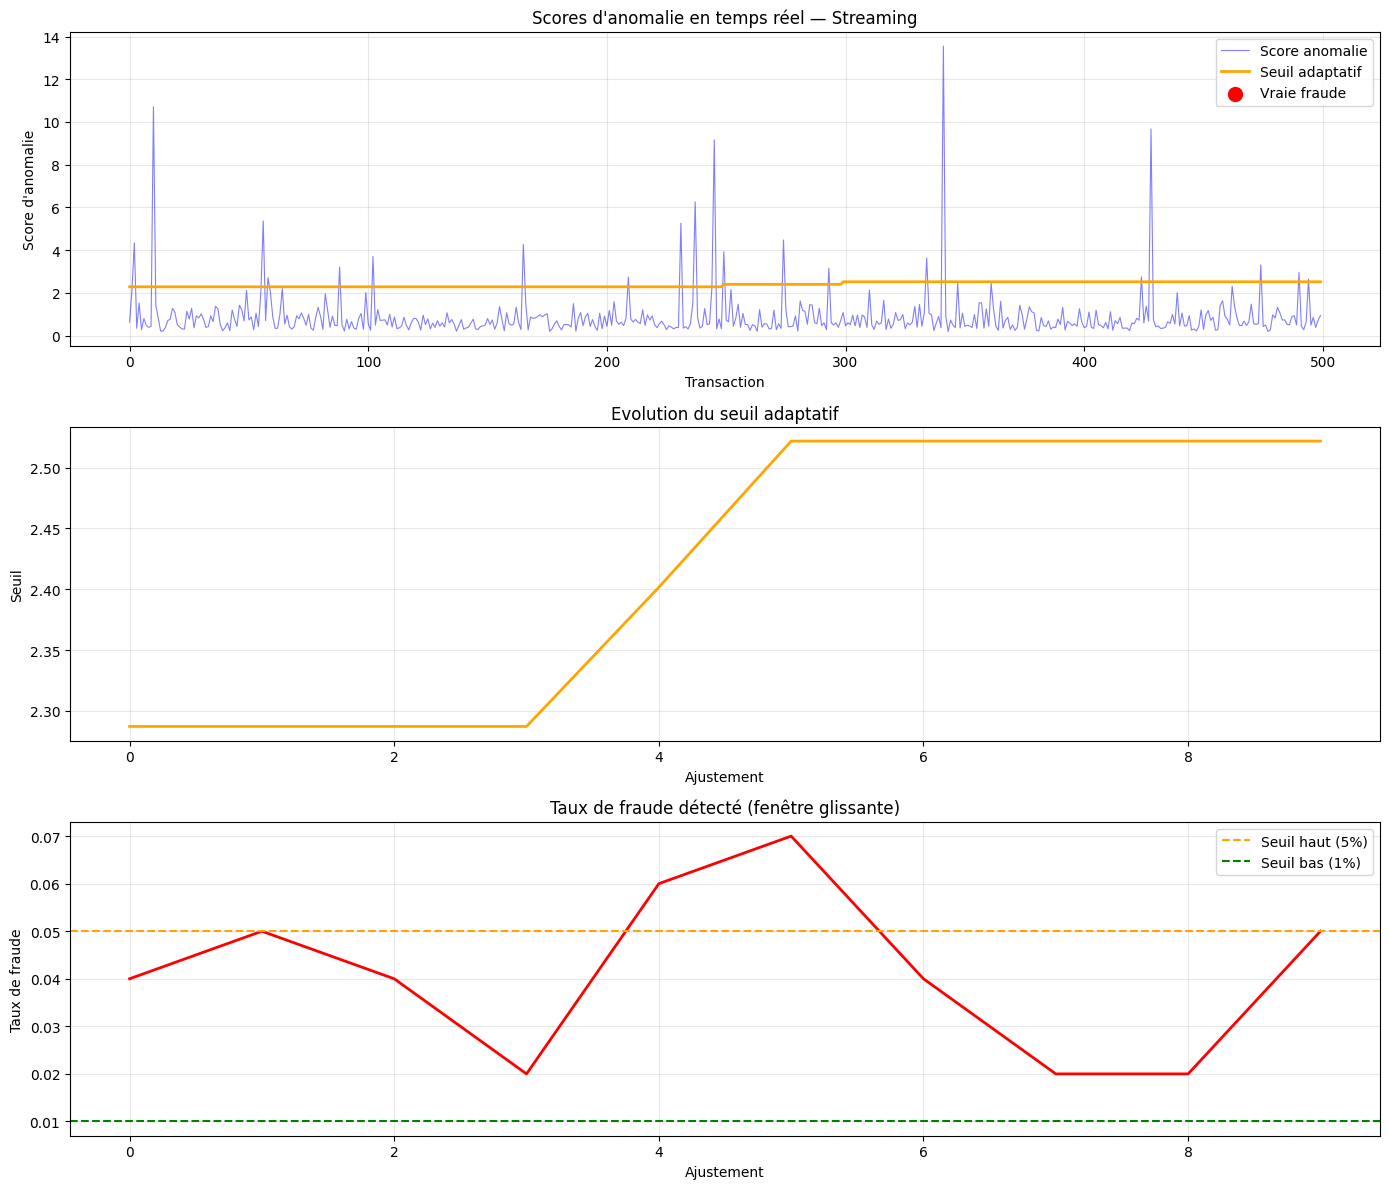

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 — Scores d'anomalie en temps réel
axes[0].plot(df_results['id'], df_results['score'], 
             color='blue', alpha=0.5, linewidth=0.8, label='Score anomalie')
axes[0].plot(df_results['id'], df_results['threshold'], 
             color='orange', linewidth=2, label='Seuil adaptatif')

# Marquer les vraies fraudes
fraudes = df_results[df_results['true_label'] == 1]
axes[0].scatter(fraudes['id'], fraudes['score'], 
                color='red', s=100, zorder=5, label='Vraie fraude')

axes[0].set_title('Scores d\'anomalie en temps réel — Streaming')
axes[0].set_xlabel('Transaction')
axes[0].set_ylabel('Score d\'anomalie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Evolution du seuil adaptatif
if pipeline.threshold_history:
    axes[1].plot(pipeline.threshold_history, color='orange', linewidth=2)
    axes[1].set_title('Evolution du seuil adaptatif')
    axes[1].set_xlabel('Ajustement')
    axes[1].set_ylabel('Seuil')
    axes[1].grid(True, alpha=0.3)

# Plot 3 — Taux de fraude détecté dans la fenêtre glissante
if pipeline.fraud_rate_history:
    axes[2].plot(pipeline.fraud_rate_history, color='red', linewidth=2)
    axes[2].axhline(y=0.05, color='orange', linestyle='--', label='Seuil haut (5%)')
    axes[2].axhline(y=0.01, color='green', linestyle='--', label='Seuil bas (1%)')
    axes[2].set_title('Taux de fraude détecté (fenêtre glissante)')
    axes[2].set_xlabel('Ajustement')
    axes[2].set_ylabel('Taux de fraude')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

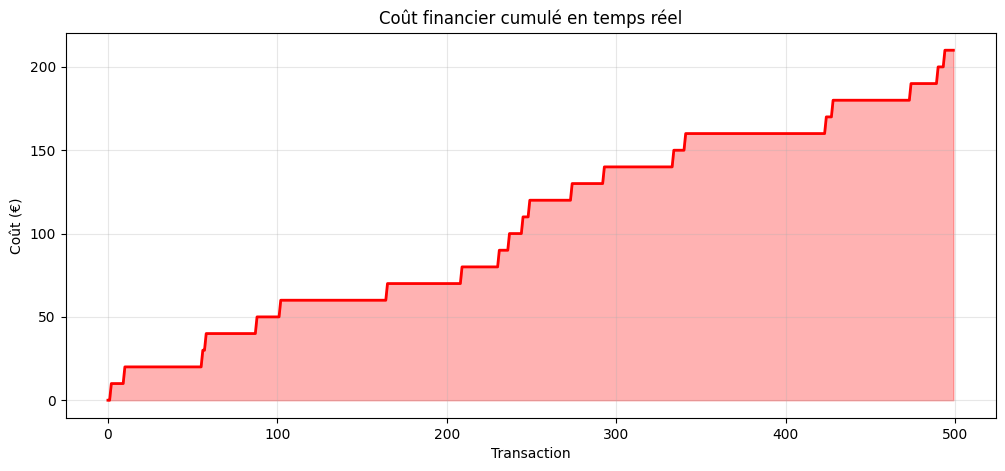


💰 Coût financier total sur 500 transactions : 210€
   - Faux positifs : 21 x 10€ = 210€
   - Faux négatifs : 0 x 500€ = 0€


In [6]:
# Simulation du coût cumulé
cout_FP = 10
cout_FN = 500

df_results['cout_cumule'] = 0
cout = 0
couts = []

for _, row in df_results.iterrows():
    if row['decision'] == 'FRAUDE' and row['true_label'] == 0:
        cout += cout_FP
    elif row['decision'] == 'NORMAL' and row['true_label'] == 1:
        cout += cout_FN
    couts.append(cout)

df_results['cout_cumule'] = couts

plt.figure(figsize=(12, 5))
plt.plot(df_results['id'], df_results['cout_cumule'], 
         color='red', linewidth=2)
plt.fill_between(df_results['id'], df_results['cout_cumule'], 
                 alpha=0.3, color='red')
plt.title('Coût financier cumulé en temps réel')
plt.xlabel('Transaction')
plt.ylabel('Coût (€)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n💰 Coût financier total sur {N_STREAM} transactions : {cout}€")
print(f"   - Faux positifs : {faux_positifs} x {cout_FP}€ = {faux_positifs*cout_FP}€")
print(f"   - Faux négatifs : {faux_negatifs} x {cout_FN}€ = {faux_negatifs*cout_FN}€")